In [1]:
import sys
sys.path.append('/home/carlau/EmissionsData/OAGScripts')

In [2]:
#import relevent packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import post_proc_util as pp_util
import re
from IPython.display import display, HTML

# change maximum display rows of pandas dataframe
pd.set_option('display.max_rows', 500)

# set figure dpi to 300
plt.rcParams['figure.dpi'] = 50
# also increase the figure font
plt.rcParams.update({'font.size': 16})

# Initial defs

In [3]:
# setup initial variables
OAG_Year_lst = [2019]
OAG_Year = OAG_Year_lst[0]
is_dataverse, inp_mod, out_mod = pp_util.get_inp_mod(OAG_Year, is_test=False)

# define specific paths
oag_path = '/home/carlau/EmissionsData/OAG_Data/'
case_path = '/net/d15/data/carlau/emisCli_io/'
split_defs_path = '/home/carlau/EmissionsData/aircraft_split_defs/'
case_name = '09_matchBoeing'
case_name = '16_matched_engines_test'


In [4]:
# load the aircraft name file
# This is a file generated by Carla based on IATA aircraft code definitions
# IATA aircraft code definitions are available in the Standard Schedules Information Manual Appendix A
# This list is from 2011, and augmented with additional newer aircraft models
aircraft_names_excel = pd.read_excel(f'{split_defs_path}/Aircraft_tables.xlsx')

# Load file from Cirium - as processed by prateek

### Load the aircraft naming definitions (From IATA SSIM manual, with additions by Carla)

In [5]:
# load the aircraft name file
aircraft_names = pd.read_excel(f'{split_defs_path}/Aircraft_tables.xlsx')

### extract and add the aircraft family names to the dataframe
## this is incase a airline only reports the family of the aircraft
# Create aircraft dataframe for aircraft families (e.g. B727 could be B727-100, B727-200, B727-200Adv, etc.)
aircraft_names_fam = aircraft_names[(aircraft_names.apply(lambda row: row['Aircraft Type'] != row['Aircraft Group'], axis=1))&
               (aircraft_names['Aircraft Type'].notna())].copy()
aircraft_names_fam['Aircraft Type'] =aircraft_names_fam['Aircraft Group']
# Add the family dataframe to the main dataframe
aircraft_names = pd.concat([aircraft_names, aircraft_names_fam], axis=0).reset_index(drop=True)

# remove duiplicates from the dataframe
# If the cirium and aircraft type are duiplicated, then this will cause errors in the downstream ratios
# Therefore, if the cirium and aircraft type are the same, only keep the first one
cols = ['Cirium-Aircraft-Code','Aircraft Type']
aircraft_names = aircraft_names.drop_duplicates(subset=cols, keep='first')
# display the remaining duplicates
print('The following dataframe should be empty - displayed aircraft names are duplicated')
display(aircraft_names[(aircraft_names['Cirium-Aircraft-Code'].notna()) & 
            (aircraft_names.duplicated(subset=cols, keep=False))].sort_values(by=['Manufacturer and Aircraft Name/Model']))


The following dataframe should be empty - displayed aircraft names are duplicated


,Manufacturer and Aircraft Name/Model,Aircraft Type,Aircraft Group,Category,Code,Cirium-Aircraft-Code


### Find, load and process the Cirium aircraft files

In [6]:
# make a list of the files in the folders in the cirium_path
# this is a list of all the files that will be processed
cirium_files = []

# need a recursive search to find all the files in the subfolders
def recursive_file_search(path, case_files):
    for root, dirs, files in os.walk(path):
        for file in files:
            case_files.append(os.path.join(root,file))
    return case_files

cirium_path = f'{split_defs_path}/cirium/Airframe_database'
cirium_files = recursive_file_search(cirium_path, cirium_files)

# filter to only keep the files that have "Processed" in the name
cirium_files = [file for file in cirium_files if (('Processed.csv' in file)&('SRC' not in file))]
# display(cirium_files)

# create a dictionary of the files, with the year of the file
# extract the year from the file names (this is the value between / and /, just before "Processed")
cirium_years_dict = {file : ((file.split('/Processed')[0]).split('/')[-1]) for file in cirium_files}

# also create a list of the case_years
case_years = list(np.sort(list(set(cirium_years_dict.values()))))

# extract a list of files for each year
cirium_files_dict = {}
for year in case_years:
    cirium_files_dict[year] = [file for file in cirium_files if cirium_years_dict[file] == year]



In [7]:
# Look at output from specific airline
OAG_Year = 2019
cirium = pd.read_csv(f'{split_defs_path}/cirium_processed/aircraft_splits_{OAG_Year}.csv')

cirium['Aircraft Type'] = cirium['Aircraft Type'].astype(str)
cirium[['Operator','Aircraft Type','Aircraft Group', 'Code', 'Cirium-Aircraft-Code', 'Total', 'fraction',
        'Manufacturer', 'Type', 'Current Family', 'Series', 'Aircraft Sub Series', 
        'Engine Series', 'Engine Master Series', 'Engine Sub Series', 'Engine Family', 'Master Series', 'Aircraft Minor Variant', 
        'APU', 'Number', 'Manufacturer and Aircraft Name/Model']].sort_values(by=['Operator', 'Aircraft Type']).reset_index(drop=True)[50:60]

,Operator,Aircraft Type,Aircraft Group,Code,Cirium-Aircraft-Code,Total,fraction,Manufacturer,Type,Current Family,...,Aircraft Sub Series,Engine Series,Engine Master Series,Engine Sub Series,Engine Family,Master Series,Aircraft Minor Variant,APU,Number,Manufacturer and Aircraft Name/Model
50,2K,32S,32S,A319,A319,10.0,0.200000,Airbus,A319,A320 Family,...,A319-112,CFM56-5B,CFM56-5,CFM56-5B6/3,CFM56,A319,112,APS3200,2,Airbus Industrie A319
51,2K,32S,32S,A319,A319,10.0,0.200000,Airbus,A319,A320 Family,...,A319-112,CFM56-5B,CFM56-5,CFM56-5B6/P,CFM56,A319,112,GTCP131-9,2,Airbus Industrie A319
52,2K,32S,32S,A320,A320,10.0,0.600000,Airbus,A320,A320 Family,...,A320-214,CFM56-5B,CFM56-5,CFM56-5B4/3,CFM56,A320,214,APS3200,6,Airbus Industrie A320
53,2P,320,32S,A320,A320,8.0,0.250000,Airbus,A320,A320 Family,...,A320-214,CFM56-5B,CFM56-5,CFM56-5B4/3,CFM56,A320,214,GTCP131-9,2,Airbus Industrie A320
54,2P,320,32S,A320,A320,8.0,0.500000,Airbus,A320,A320 Family,...,A320-214,CFM56-5B,CFM56-5,CFM56-5B4/3 PIP,CFM56,A320,214,GTCP131-9,4,Airbus Industrie A320
55,2P,320,32S,A320,A320,8.0,0.250000,Airbus,A320,A320 Family,...,A320-214,CFM56-5B,CFM56-5,CFM56-5B4/P,CFM56,A320,214,GTCP131-9,2,Airbus Industrie A320
56,2P,321,32S,A321,A321,6.0,0.666667,Airbus,A321,A320 Family,...,A321-231,V2533,V2500-A5,V2533-A5SelectOne,V2500,A321,231,GTCP131-9,4,Airbus Industrie A321
57,2P,321,32S,A321,A321,6.0,0.333333,Airbus,A321,A320 Family,...,A321-231,V2533,V2500-A5,V2533-A5SelectTwo,V2500,A321,231,GTCP131-9,2,Airbus Industrie A321
58,2P,32A,32S,A320,A320,8.0,0.250000,Airbus,A320,A320 Family,...,A320-214,CFM56-5B,CFM56-5,CFM56-5B4/3,CFM56,A320,214,GTCP131-9,2,Airbus Industrie A320 (sharklets)
59,2P,32A,32S,A320,A320,8.0,0.500000,Airbus,A320,A320 Family,...,A320-214,CFM56-5B,CFM56-5,CFM56-5B4/3 PIP,CFM56,A320,214,GTCP131-9,4,Airbus Industrie A320 (sharklets)


In [8]:

# del cirium_all
# 
for OAG_Year in (list(range(1980, 2016, 5)) + [2019]):
# for OAG_Year in [1990]:

# for OAG_Year in OAG_Year_lst:


    # load the cirium data
    cirium = pd.read_csv(f'{split_defs_path}/cirium_processed/aircraft_splits_{OAG_Year}.csv')

    cirium = cirium[cirium['Operator']!='ALL_CARRIERS']

    cirium = cirium.drop_duplicates(subset=['Operator','Manufacturer', 'Type','Current Family', 'Series',
        'Aircraft Sub Series','Engine Series', 'Engine Master Series', 
        'Engine Sub Series', 'Engine Family', 'Master Series', 
        'Aircraft Minor Variant',  
        'APU'], keep='first')

    cirium['OAG_Year'] = OAG_Year

    if OAG_Year == 1980:
        cirium_all = cirium.copy()
    else:
        cirium_all = pd.concat([cirium_all,cirium])



In [19]:
from IPython.display import display, HTML


# Sample aircraft and engine list
aircraft_of_interest = [
    'A388 Trent97284', 'B744 RB211524H', 'B744 RB211524HT', 'B788 GEnx1B70', 'B789 Trent1000K2', 'B788 GEnx1B70P1', 
     'B788 Trent1000D2', 'B788 GEnx1B7075P1', 'B772 PW4074', 'A320N LEAP1A2626E1', 'B772 Trent884', 'A321N LEAP1A35A3333B23230', 
     'B744 RB211524G', 'B789 Trent1000D3', 'B789 Trent1000K3', 'B78X GEnx1B76AP2', 'B789 Trent1000D2', 'B772 PW4084', 
     'B744 PW4062', 'A318 CFM565B83', 'B789 GEnx1B64P2', 'A320 CFM565B4', 'B762 PW4062', 'B762 CF680A', 'A338 Trent700072', 
     'A337 Trent772', 'B762 CF680A2', 'B773 GE90115B', 'A320 CFM565B43', 'B738 CFM567B26E', 'A320 V2527A5', 'A388 GP7270', 
     'B789 GEnx1B7475P2', 'A321 V2533A5', 'B738 CFM567B26', 'A333 Trent772', 'A321 CFM565B33', 'B738 CFM567B24E', 'A320 CFM565B4P', 
     'B737 CFM567B22', 'B738 CFM567B263', 'A388 Trent97084', 'A332 Trent772', 'B789 Trent1000J2', 'A320 CFM565B63', 'B739 CFM567B26E', 
     'A319 CFM565B5P', 'B739 CFM567B27E', 'B772 Trent892', 'A319 V2524A5', 'B788 Trent1000G2', 'B772 GE90110B1', 'A319 CFM565B6P', 
     'B789 Trent1000J3', 'B737 CFM567B223', 'A332 CF680E1A3', 'B788 GEnx1B70P2', 'B738 CFM567B27', 'A319 CFM565A5', 'B772 GE9094B', 
     'B738 CFM567B243', 'A333 CF680E1A3', 'B764 CF680C2B8F', 'B788 GEnx1B7075P2', 'A319 CFM565B73', 'A321 CFM565B3P', 'B772 PW4090', 
     'A319 V2522A5', 'A333 PW4168A1D', 'A332 CF680E1A4', 'B744 CF680C2B1F', 'A333 CF680E1A4', 'B772 Trent895', 'B739 CFM567B263', 
     'B773 Trent892', 'B737 CFM567B24', 'B738 CFM567B27E', 'A333 PW4170', 'A320 V2527A5E', 'A319 CFM565B63', 'B788 GEnx1B67P2', 
     'A320 CFM565A1', 'B738 CFM567B24', 'B763 CF680C2B6F', 'A319 CFM565B53', 'B788 Trent1000CE3', 'B763 PW4060', 'A332 PW4168A1D', 
     'A320 CFM565A3', 'B772 PW4077', 'B773 PW4090', 'B738 CFM567B27EB1F', 'B738 CFM567B273', 'B788 GEnx1B64P2', 'B744 CF680C2B5F', 
     'A339 Trent700072', 'B737 CFM567B20', 'A320 CFM565B6P', 'A321 CFM565B23', 'A333 PW4168A', 'A320 V2527EA5', 'A332 PW4170', 
     'B789 GEnx1B76AP2', 'B772 GE9085B', 'B78X Trent1000M3', 'A319 CFM565B7P', 'A332 PW4168A', 'A321 V2530A5', 'B78X GEnx1B76P2', 
     'A319 V2527A5M', 'B738 CFM567B27EF', 'B737 CFM567B24E', 'A321 CFM565B1P', 'B772 GE90115B', 'B772 GE9090B', 'B763 CF680C2B6', 
     'B763 PW4062', 'B739 CFM567B26', 'B788 GEnx1B64P1', 'A319 V2527MA5', 'A318 CFM565B8P', 'B788 GEnx1B67P1', 'A320 CFM565B42P', 
     'B78X GEnx1B7475P2', 'B789 GEnx1B7075P2', 'B763 CF680C2B7F', 'A321 CFM565B2P', 'A20N PW1127GJM', 'B788 Trent1000AE3', 
     'B744 PW4056', 'B736 CFM567B20', 'A21N PW1133GJM', 'B737 CFM567B243', 'A319 CFM565B62P', 'B739 CFM567B27EF', 'B736 CFM567B22', 
     'B737 CFM567B263', 'A333 Trent768', 'B762 CF680C2B8F', 'A333 PW4168', 'B737 CFM567B26', 'B737 CFM567B203', 'B789 GEnx1B70P2', 
     'B772 Trent875', 'A321 CFM565B13', 'A321 CFM565B32P', 'A318 CFM565B93', 'B763 PW4056', 'B737 CFM567B26E', 'B738 CFM567B27EB1', 
     'B737 CFM567B22E', 'B763 PW4152', 'B763 PW4x52', 'B772 GE9076B', 'B772 PW4074D', 'B763 CF680C2B2F', 'A320 V2500A1', 
     'B788 Trent1000G3', 'A319 CFM565A4', 'B738 CFM567B27AE', 'B763 CF680C2B2', 'A318 CFM565B9P', 'A21N PW1130GJM', 
     'B737 CFM567B26EB2', 'B762 PW4056', 'B737 CFM567B27', 'B737 CFM567B273', 'B763 CF680C2B4', 'A20N PW1127GAJM', 
     'B737 CFM567B27AE', 'B764 CF680C2B7F', 'B739 CFM567B273', 'B737 CFM567B27E', 'B763 CF680C2B4F', 'B738 CFM567B27EB3', 
     'B737 CFM567B27EB3'
]

# Convert 'Build Year mean' to integer
cirium_all['Build Year mean'] = cirium_all['Build Year mean'].astype(float).astype(int)

import re

# Function to extract only the alphabetic part of an engine name
def extract_letter_part(engine_name):
    return re.sub(r'[^A-Za-z]', '', engine_name)  # Remove numbers, hyphens, etc.

# Function to match aircraft exactly and allow flexible engine matching
def match_aircraft_engine(row):
    for entry in aircraft_of_interest:
        aircraft, engine = entry.split(' ')  # Split into aircraft and engine
        
        # Extract the core name (letters only) for better matching
        engine_cleaned = extract_letter_part(engine)  
        engine_cleaned_row = extract_letter_part(row['Engine Series'])  

        # Direct substring check (generalized for all engines)
        if engine_cleaned in engine_cleaned_row:
            return True

        # Check if aircraft name contains all characters in the dataset
        if contains_all_chars(row['Code'], aircraft):
            return True
    
    return False

# Apply the updated function
filtered_cirium = cirium_all[cirium_all['Build Year mean'] > 2009]
final_cirium = filtered_cirium[filtered_cirium.apply(match_aircraft_engine, axis=1)].drop_duplicates(subset=['Code', 'Engine Series'], keep='first')

# Print results
print("Build Year of aircraft in the interest list:")
# Save the filtered dataframe to a CSV file
final_cirium.to_csv(f'filtered_cirium_{year}.csv', index=False)

# Display the filtered dataframe
display(HTML(final_cirium[['Code', 'Build Year mean', 'Engine Series']].to_html(max_rows=None)))


Build Year of aircraft in the interest list:


,Code,Build Year mean,Engine Series
89,A320,2010,CFM56-5B
202,A321,2010,V2533
205,A332,2010,Trent 772
374,A319,2010,V2524
919,DH8D,2010,PW150
1070,B738,2010,CFM56-7B
8527,A332,2010,CF6-80E1
9405,B773,2010,GE90-115B
9509,A320,2010,V2527
9875,B788,2010,GEnx-1B64


/tmp/ipykernel_3237160/2670912028.py:5: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  cirium_all_grpd = cirium_all[['OAG_Year', col, 'Number']].groupby(['OAG_Year', col]).aggregate(sum).unstack(col).fillna(0)
/tmp/ipykernel_3237160/2670912028.py:5: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  cirium_all_grpd = cirium_all[['OAG_Year', col, 'Number']].groupby(['OAG_Year', col]).aggregate(sum).unstack(col).fillna(0)


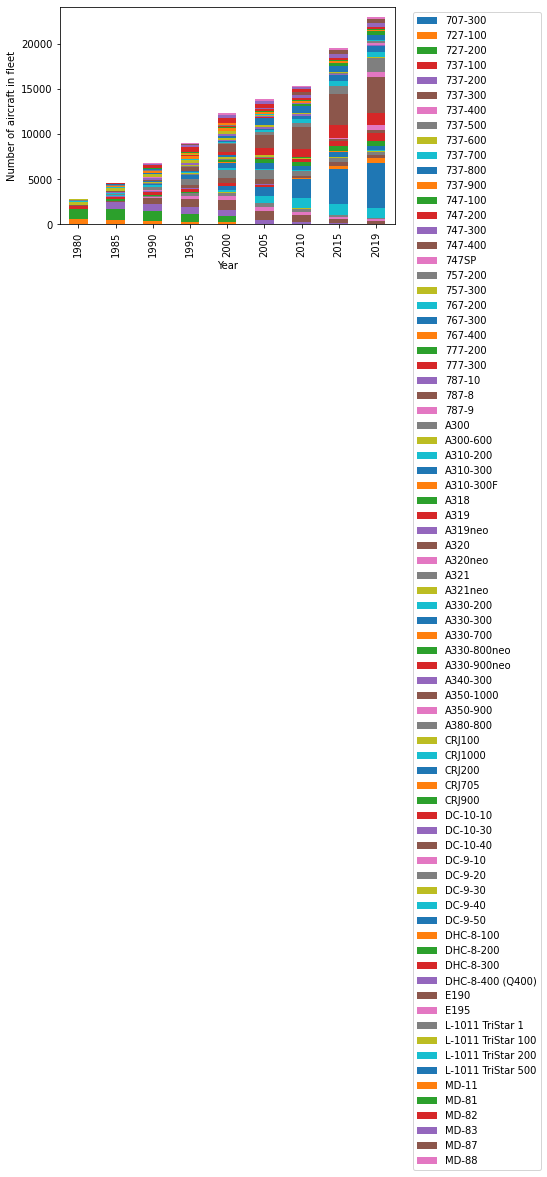

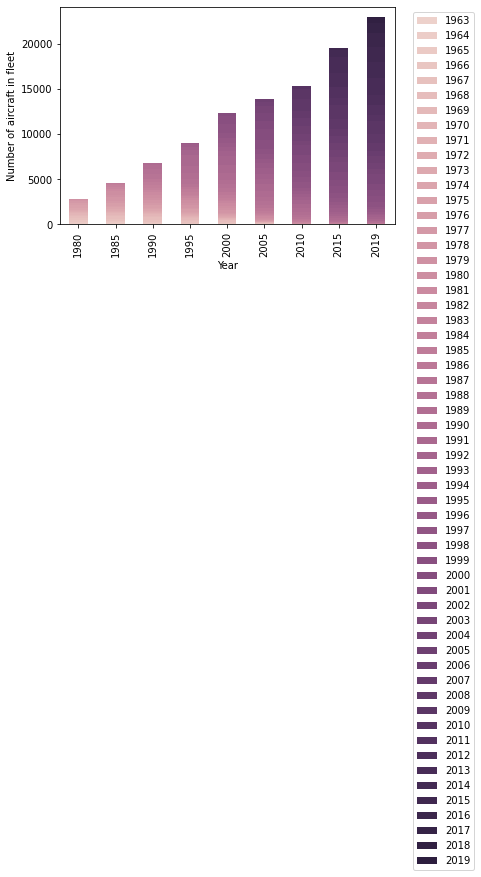

In [10]:
for col in ['Master Series', 'Build Year mean']:
    fig, ax = plt.subplots()

    cirium_all[col] = cirium_all[col].astype(str)
    cirium_all_grpd = cirium_all[['OAG_Year', col, 'Number']].groupby(['OAG_Year', col]).aggregate(sum).unstack(col).fillna(0)
    cirium_all_grpd.columns = cirium_all_grpd.columns.get_level_values(1)

    N = cirium_all_grpd.shape[1]

    if col == 'Build Year mean':
        colors = sns.cubehelix_palette(n_colors=N)
    else:
        colors = None

    cirium_all_grpd.plot.bar(stacked=True, ax=ax, color=colors)

    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    ax.set_ylabel('Number of aircraft in fleet')
    ax.set_xlabel('Year')

/tmp/ipykernel_3237160/12479929.py:10: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  cirium_all_grpd = cirium_all[['OAG_Year',col, 'Number']].groupby(['OAG_Year',col]).aggregate(sum).unstack(col).fillna(0)
/tmp/ipykernel_3237160/12479929.py:10: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  cirium_all_grpd = cirium_all[['OAG_Year',col, 'Number']].groupby(['OAG_Year',col]).aggregate(sum).unstack(col).fillna(0)
/tmp/ipykernel_3237160/12479929.py:10: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used d

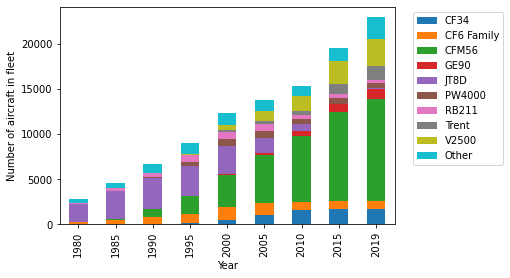

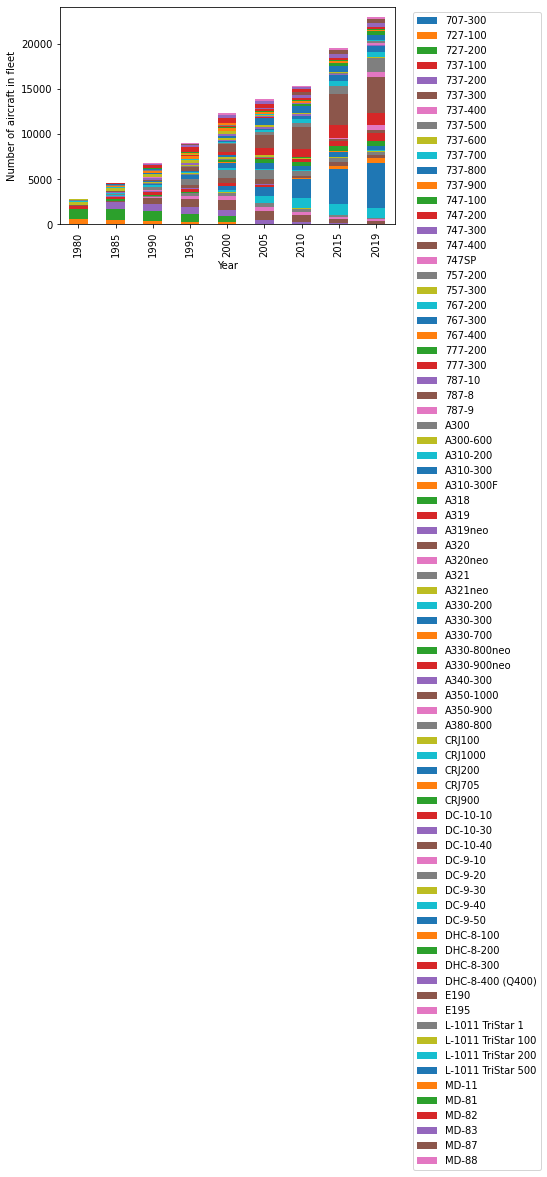

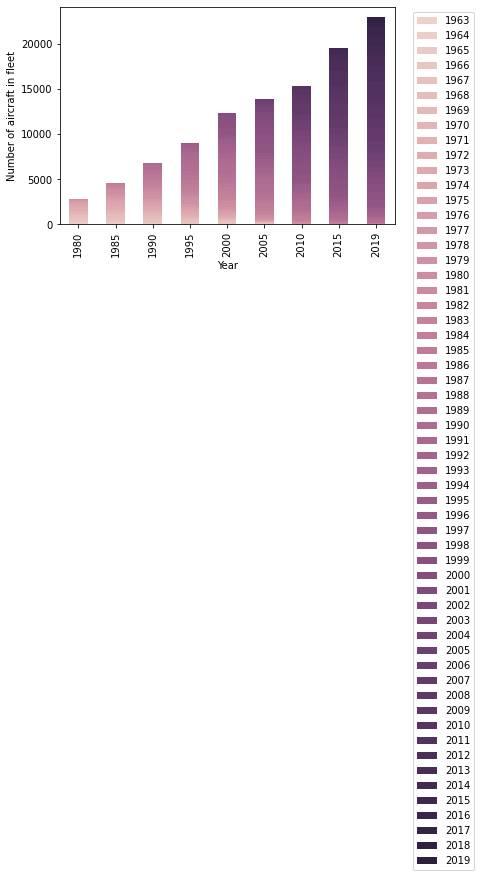

In [11]:
for col in ['Engine Family', 'Master Series','Build Year min']:
    fig, ax = plt.subplots()

    cirium_all[col] = cirium_all[col].astype(str)
    if col == 'Engine Family':
        # rename the columns
        engine_lst_other = ['PW6000','JT3D', 'RB.183 Tay', 'GP7200', 'PW1000G','LEAP', 'GEnx', 'PW2000', 'JT9D', 'PW100']
        cirium_all['Engine Family'] = cirium_all['Engine Family'].apply(lambda x: x if x not in engine_lst_other else 'Other')

    cirium_all_grpd = cirium_all[['OAG_Year',col, 'Number']].groupby(['OAG_Year',col]).aggregate(sum).unstack(col).fillna(0)
    # rename columns to drop the "number"
    cirium_all_grpd.columns = cirium_all_grpd.columns.get_level_values(1)
    # cirium_all_grpd

    # Number of colors needed
    N = cirium_all_grpd.shape[1]

    if 'Other' in cirium_all_grpd.columns:
        # change the columns to set "other" last
        columns = cirium_all_grpd.columns
        cirium_all_grpd = cirium_all_grpd[[col for col in columns if col != 'Other']+['Other']]

    if col == 'Build Year min':
        # Create a sequential color palette
        colors = sns.cubehelix_palette(n_colors=N)
    else:
        colors = None

    cirium_all_grpd.plot.bar(stacked=True, ax=ax, color=colors)

    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    ax.set_ylabel('Number of aircraft in fleet')
    ax.set_xlabel('Year')
